In [1]:
import datetime
import blitzortung
import numpy as np
import fastcluster
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

In [4]:
strikes_db = blitzortung.db.strike()
strikes = strikes_db.select(blitzortung.db.TimeInterval(datetime.datetime.now(datetime.UTC)-datetime.timedelta(hours=1)))
len(strikes)

12499

In [5]:
coordinates = np.ndarray([len(strikes), 2])

for index, strike in enumerate(strikes):
    coordinates[index][0] = strike.get_x()
    coordinates[index][1] = strike.get_y()

In [6]:
%time clusters = fastcluster.linkage(coordinates)

CPU times: user 1.23 s, sys: 196 ms, total: 1.42 s
Wall time: 1.42 s


In [89]:
number_of_clusters = len(clusters)

def walk_tree(index, depth=0):
    global clusters, number_of_clusters
    if index >= number_of_clusters:
        index -= number_of_clusters
        cluster = clusters[index]
        index_1 = int(cluster[0])
        index_2 = int(cluster[1])
        distance = cluster[2]
        number_of_elements = int(cluster[0])
        print "%s%d %d %.4f %d" %(depth * "  ", index_1, index_2, distance, number_of_elements)
        walk_tree(index_1, depth + 1)
        walk_tree(index_2, depth + 1)
    else:
        pass
        #print coordinates[index] 

walk_tree(number_of_clusters * 2)

IndexError: index 3901 is out of bounds for axis 0 with size 3901

3901


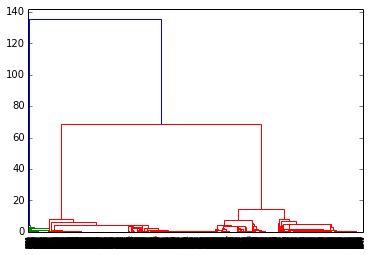

{'color_list': ['g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',
  'g',

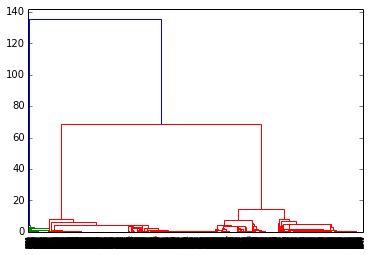

In [81]:
dendrogram(clusters)

In [82]:
distances = [(int(cluster[0]), int(cluster[1]), cluster[2], int(cluster[3])) for cluster in clusters]

In [85]:
len(distances)

3901

In [83]:
distances[:10],distances[-10:]

([(2721, 3372, 0.0002312249986513723, 2),
  (2608, 2609, 0.00027679776010606507, 2),
  (898, 899, 0.00036272992707620525, 2),
  (2847, 3367, 0.0003924856685368449, 2),
  (1236, 1237, 0.0005153406640262553, 2),
  (115, 117, 0.00064965914140107924, 2),
  (2346, 2718, 0.00067426552633807063, 2),
  (2283, 2377, 0.00069812104967540008, 2),
  (116, 119, 0.00071276924736566119, 2),
  (28, 135, 0.00075365575695506785, 2)],
 [(7488, 7777, 5.4774588757537028, 30),
  (6919, 7790, 5.7298920220162124, 309),
  (7563, 7789, 6.0358725347559332, 1917),
  (7785, 7792, 6.9070353370609689, 960),
  (7787, 7794, 7.5963928835821077, 735),
  (7688, 7795, 7.9744927667796501, 1938),
  (7793, 7796, 8.1646530021191399, 990),
  (7797, 7799, 14.504806894960476, 1725),
  (7798, 7800, 68.72794812508468, 3663),
  (7783, 7801, 135.34313324148937, 3902)])

In [34]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import shapely.geometry as sgeom

In [46]:
points = [sgeom.Point(point) for point in coordinates]

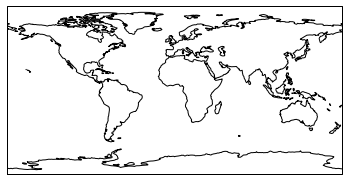

In [56]:
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_geometries(points, ccrs.PlateCarree())
ax

In [58]:
ax.add_geometries(points, ccrs.PlateCarree())

In [50]:
plt.axes?